# CPWL operator timing against the SVD, tolerance-stopped
Timing against the SVD (exp4), re-run on the CPWL spectral operator of exp6 (the $\mathrm{clip}$ profile by default): every internal $\mathrm{Sgn}$ call inside the operator's sign form is run with `sign_map.make_sgn_ns_until` until it reaches a residual tolerance $\varepsilon$ instead of a fixed iteration count $K_D$. Both routes evaluate the same CPWL operator on the same matrix, against the exact operator read off a signed SVD (`cpwl_operator.spectral_reference`). Each of the `n_reps` repetitions uses a new random matrix of the same size and $\sigma_{\min}$, so the reported std is over matrices. Edit the config and rerun; set `devices=["cpu"]` without a GPU.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.cpwl_svd_timing import CPWLSvdTimingConfig, run_cpwl_svd_timing, cpwl_results_table
%matplotlib inline

In [8]:
cfg = CPWLSvdTimingConfig(
    sizes=[256], smins=[1e-2, 1e-3, 1e-4, 1e-5, 1e-6], degrees=[1, 2, 3, 4],
    devices=["cuda"], n_fixed=256, dtype=torch.float64,
    profile="clip", alpha=-0.5, beta=0.5,
    eps=1e-8,     # residual target for every internal sign call
    k_max=50,     # step cap per sign call; one that misses eps is flagged
    power_iters=10, power_margin=1.1,
    time_unit="ms", time_round_digits=2,
    n_warmup=2, n_reps=10, cpu_threads=None, seed=0,
)
res = run_cpwl_svd_timing(cfg)

n=256 smin=0.01: 10 matrices
  cuda: svd 455.97 ms | D=1 87.31 ms (calls=3.0, max K=17) | D=2 76.14 ms (calls=3.0, max K=11) | D=3 76.62 ms (calls=3.0, max K=9) | D=4 76.65 ms (calls=3.0, max K=8)
n=256 smin=0.001: 10 matrices
  cuda: svd 508.20 ms | D=1 95.12 ms (calls=3.0, max K=22) | D=2 83.26 ms (calls=3.0, max K=14) | D=3 81.01 ms (calls=3.0, max K=11) | D=4 84.77 ms (calls=3.0, max K=10)
n=256 smin=0.0001: 10 matrices
  cuda: svd 565.53 ms | D=1 109.70 ms (calls=3.0, max K=27) | D=2 96.63 ms (calls=3.0, max K=18) | D=3 95.14 ms (calls=3.0, max K=14) | D=4 99.20 ms (calls=3.0, max K=12)
n=256 smin=1e-05: 10 matrices
  cuda: svd 628.08 ms | D=1 118.25 ms (calls=3.0, max K=33) | D=2 102.63 ms (calls=3.0, max K=21) | D=3 104.04 ms (calls=3.0, max K=17) | D=4 108.31 ms (calls=3.0, max K=15)
n=256 smin=1e-06: 10 matrices
  cuda: svd 685.35 ms | D=1 131.26 ms (calls=3.0, max K=39) | D=2 115.43 ms (calls=3.0, max K=25) | D=3 112.15 ms (calls=3.0, max K=20) | D=4 120.12 ms (calls=3.0, max

## Time against size and against $\sigma_{\min}$

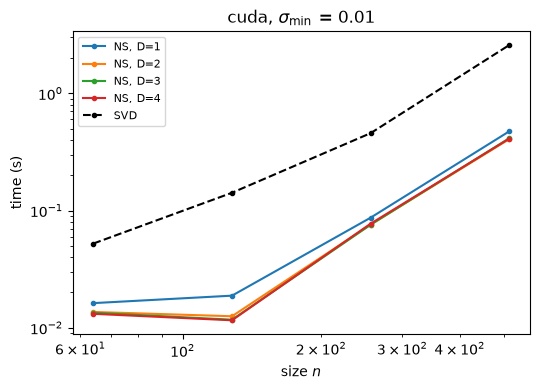

In [7]:
smin_plot = 1e-2  # sigma_min shown in the time-vs-size panel and the table
fig, axs = plt.subplots(1, len(res["cfg"].devices), figsize=(5.5 * len(res["cfg"].devices), 4), squeeze=False)
for ax, device in zip(axs[0], res["cfg"].devices):
    plots.plot_time_vs_size(res, device, smin_plot, ax=ax)
fig.tight_layout()

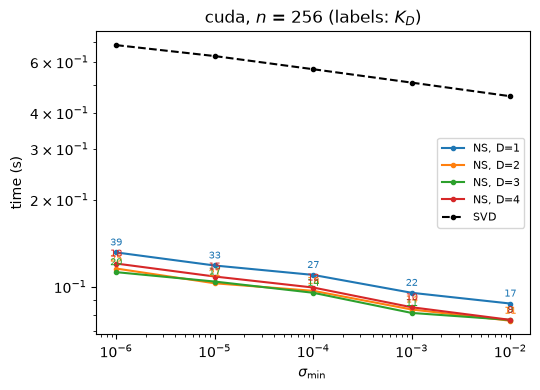

In [9]:
fig, axs = plt.subplots(1, len(res["cfg"].devices), figsize=(5.5 * len(res["cfg"].devices), 4), squeeze=False)
for ax, device in zip(axs[0], res["cfg"].devices):
    plots.plot_time_vs_smin(res, device, ax=ax)
fig.tight_layout()

## Results table
Relative Frobenius error against the exact CPWL operator, evaluation time, number of internal sign-map calls, and the largest iteration count any of those calls needed to reach $\varepsilon$, one row per degree $D$.

In [5]:
for device in res["cfg"].devices:
    cpwl_results_table(res, device, cfg.sizes[0], smin_plot)
    print()

CPWL operator (clip), tolerance eps = 1e-08, mean/max over 10 matrices: cuda, n = 64, smin = 0.0001
     rel. Frobenius error  time      # sign calls  max K
D=1  5.30e-10              20.24 ms  3.0           27   
D=2  5.26e-12              16.96 ms  3.0           18   
D=3  2.99e-14              16.32 ms  3.0           14   
D=4  1.74e-10              17.29 ms  3.0           13   

